Mount Google Drive:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Extract Dataset from ZIP File:

In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/Space project/Collision Avoidance Challenge - Dataset.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Verify Extracted Files:

In [ ]:
import os
os.listdir('/content/dataset')

['Collision Avoidance Challenge - Dataset']

In [ ]:
os.listdir('/content/dataset/Collision Avoidance Challenge - Dataset')

['raw_data', 'kelvins_competition_data']

In [ ]:
os.listdir('/content/dataset/Collision Avoidance Challenge - Dataset/kelvins_competition_data')

['test_data_private.csv', 'train_data.zip', 'test_data.csv']

Extract TRAIN DATA ZIP:

In [ ]:
import zipfile

zip_path = '/content/dataset/Collision Avoidance Challenge - Dataset/kelvins_competition_data/train_data.zip'
extract_path = '/content/dataset/train_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Verify Final CSV:

In [ ]:
import os
os.listdir('/content/dataset/train_data')

['train_data.csv']

Load Dataset:

In [ ]:
import pandas as pd
df = pd.read_csv('/content/dataset/train_data/train_data.csv')

Data Exploration:

In [ ]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162634 entries, 0 to 162633
Columns: 103 entries, event_id to AP
dtypes: float64(98), int64(4), object(1)
memory usage: 127.8+ MB


 Machine Learning Pipeline:

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import resample


# Data preprocessing

# Define the features
features = [
    'time_to_tca',
    'relative_speed',
    'relative_position_r',
    't_sigma_r',
    'c_sigma_r'
]

# Missing value analysis
df[features].isnull().sum()

# Fill missing values with median
df[features] = df[features].fillna(df[features].median())

# 2. Define Target (Using Industry Standard Risk)

# We use -6 (10^-6 probability) so the model has enough "Risk" cases to study.
df['collision'] = (df['risk'] > -6).astype(int)


# 3. Split Data

X = df[features]
y = df['collision']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# 4. Balanced Upsampling (Fixing the Imbalance)

train_df = pd.concat([X_train, y_train], axis=1)

df_majority = train_df[train_df['collision'] == 0]
df_minority = train_df[train_df['collision'] == 1]

# Upsample the minority class (Risk) to match the majority (Safe)
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

train_balanced = pd.concat([df_majority, df_minority_upsampled])

X_train_final = train_balanced[features]
y_train_final = train_balanced['collision']


# 5. Train Model

# We use 'balanced' class weights AND the upsampled data for maximum sensitivity
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_final, y_train_final)


# 6. Evaluate

pred = model.predict(X_test)

print("--- Classification Report ---")
print(classification_report(y_test, pred))


# 7. Test with New Data

new_data = pd.DataFrame([{
    'time_to_tca': 1.5,           # Close in time (days)
    'relative_speed': 14000,      # High orbital velocity (m/s)
    'relative_position_r': 50,    # Very close radial distance (m)
    't_sigma_r': 10,              # Uncertainty
    'c_sigma_r': 15
}])

# Match the training feature order
new_data = new_data[features]

prediction = model.predict(new_data)
risk_prob = model.predict_proba(new_data)[0][1]

print(f"\nPrediction: {'Collision Risk!' if prediction[0] == 1 else 'Safe'}")
print(f"Risk Probability: {risk_prob:.2%}")

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.80      0.88     30491
           1       0.23      0.89      0.36      2036

    accuracy                           0.80     32527
   macro avg       0.61      0.84      0.62     32527
weighted avg       0.94      0.80      0.85     32527


Prediction: Safe
Risk Probability: 41.93%


ROC-AUC curve:

In [ ]:
from sklearn.metrics import roc_auc_score

# Calculate the AUC score
auc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.9112


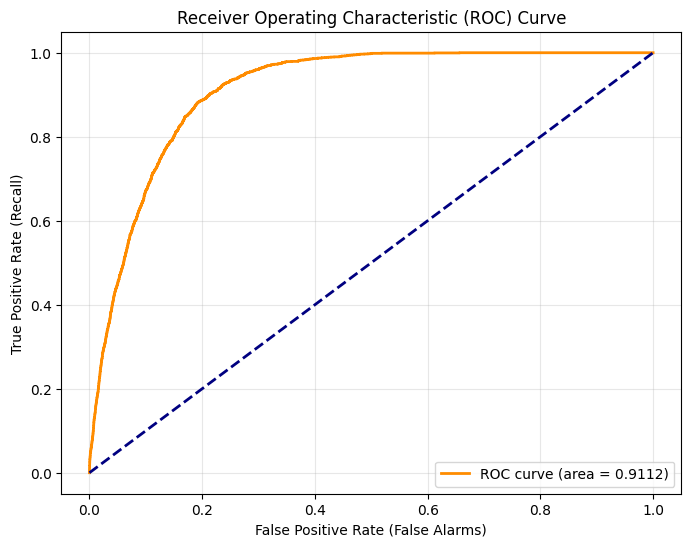

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Get probabilities for the positive class
y_probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()